# Hello Quantum World!

Welcome to your first quantum program! In this notebook we will build the **Bell state** – the simplest example of two entangled qubits – and run it both on a local simulator and on a real IBM Quantum computer.

This notebook has been updated to the **modern Qiskit (>= 1.0 / 2.x) API**, which is significantly different from the Qiskit you might find in older tutorials. The main changes vs. the original 2021 version are:

| Old API (deprecated/removed) | New API |
|---|---|
| `from qiskit import *` | Explicit imports of what you need |
| `Aer.get_backend("qasm_simulator")` | `from qiskit_aer import AerSimulator` |
| `execute(circuit, backend=...)` | `transpile(...)` + `backend.run(...)` (or a primitive) |
| `IBMQ.load_account()` / `IBMQ.get_provider(...)` | `from qiskit_ibm_runtime import QiskitRuntimeService` |
| `provider.get_backend("ibmq_lima")` | `service.least_busy(...)` or `service.backend("ibm_brisbane")` |
| `execute(circuit, backend=qpu)` | `SamplerV2(mode=qpu).run([isa_circuit])` |

### Required packages

```bash
pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc
```

> If you only want to use the local simulator, you can skip `qiskit-ibm-runtime`.

In [1]:
#!pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc
#import sys
#!{sys.executable} -m pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

## Creating a Quantum Circuit

A `QuantumCircuit` is the core object in Qiskit. It holds:

- the **qubits** we will operate on,
- the **gates** (operations) we apply to them, and
- the **classical bits** used to record measurement outcomes.

Here we create a circuit with **2 qubits and 2 classical bits**.

In [15]:
circuit = QuantumCircuit(2,2)

### Alternative: explicit registers

Some Qiskit programs declare the quantum and classical registers separately. The result is identical, but giving registers explicit names is handy when a circuit has many of them.

In [16]:
#quantum_register = QuantumRegister(2)
#classical_register = ClassicalRegister(2)
#circuit = QuantumCircuit(quantum_register,classical_register)

## Drawing the Circuit

`circuit.draw()` returns a textual diagram of the circuit. Passing `output="mpl"` produces a nicer matplotlib-rendered drawing (the one we'll use throughout the rest of the course).

The circuit currently has nothing in it – the next cells will add gates one by one.

In [17]:
circuit.draw()

q_0: 
     
q_1: 
     
c: 2/

In [18]:
%matplotlib inline

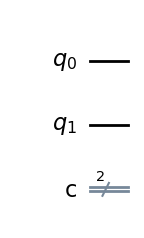

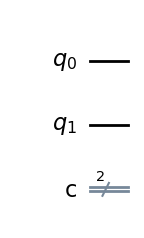

In [19]:
circuit.draw(output='mpl')

## Putting a Qubit in Superposition – the Hadamard Gate

The **Hadamard gate (`H`)** rotates a qubit from one of the basis states (|0⟩ or |1⟩) into an *equal superposition* of both. It is the gate that turns a classical bit into a true "quantum" bit.

Here we apply it to qubit 0.

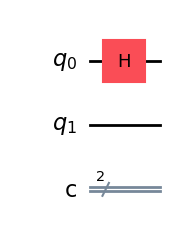

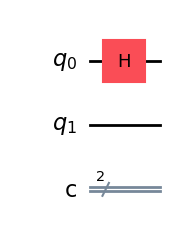

In [20]:
circuit.h(0)
circuit.draw(output='mpl')

## Entanglement and Measurement

The **controlled-NOT (CNOT / CX)** gate flips the target qubit *only* when the control qubit is in state |1⟩.

When we apply `H` to qubit 0 first and then `CX(0, 1)`, the two qubits become **entangled** in a Bell state. Measuring either qubit instantly tells us what the other one will give: they are perfectly correlated.

`circuit.measure([0, 1], [0, 1])` measures qubit 0 → classical bit 0, qubit 1 → classical bit 1.

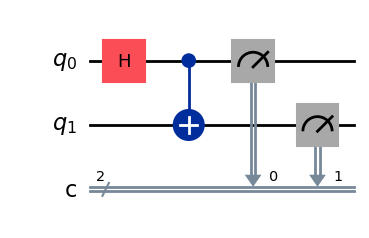

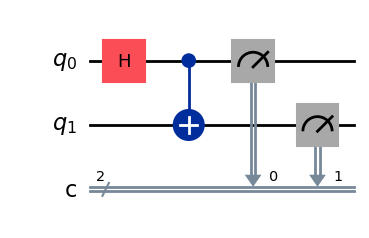

In [21]:
circuit.cx(0,1) # 0-> control qubit, 1-> target qubit
circuit.measure([0,1],[0,1])
circuit.draw(output='mpl')

## Running on a Local Simulator

Before sending anything to a real quantum computer it's a good idea to test it on a classical simulator. Qiskit Aer is the high-performance simulator package.

In modern Qiskit the old `Aer.get_backend("qasm_simulator")` call has been replaced by importing `AerSimulator` directly from the `qiskit_aer` package and instantiating it.

Then, instead of the old `execute(circuit, backend)` helper (which has been **removed**) we:

1. **Transpile** the circuit for the simulator – this rewrites it using basis gates the simulator understands.
2. Call `simulator.run(...)` to actually run it and `.result()` to get the outcome.

In [22]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

In [23]:
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()

### Visualizing the Results

`plot_histogram` shows how often each measurement outcome occurred. For our Bell state we expect roughly **50% `00`** and **50% `11`** – almost never `01` or `10`. That correlation is the signature of entanglement.

In [24]:
from qiskit.visualization import plot_histogram

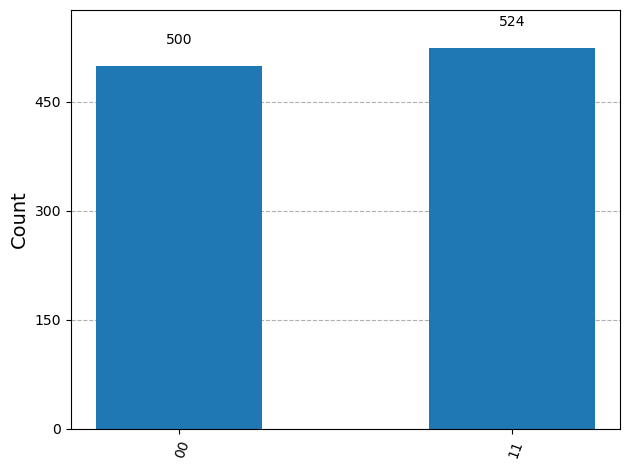

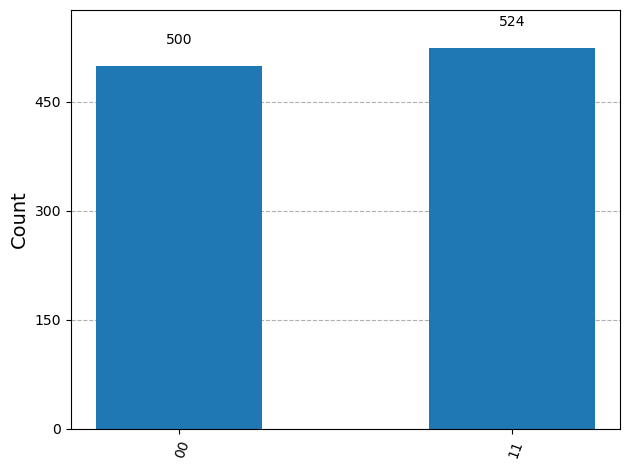

In [25]:
counts = result.get_counts(circuit)
plot_histogram(counts)

## Running on Real IBM Quantum Hardware

So far we used a local simulator – good for learning, but the real fun is running circuits on actual quantum hardware! For that we need:

1. The `qiskit-ibm-runtime` package.
2. A free IBM Quantum account at <https://quantum.ibm.com> (the legacy `IBMQ.load_account()` workflow has been replaced).
3. Your **API token** saved locally with `QiskitRuntimeService.save_account(...)`.

Once that's done we just create a `QiskitRuntimeService()` – the modern equivalent of the old `provider`.

In [32]:
from qiskit_ibm_runtime import QiskitRuntimeService

# The first time you run this, save your account once with your IBM Quantum API token:
#QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="PUT_YOUR_TOKEN_HERE",
#     overwrite=True,
#)

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-05-02 14:25:34,316: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [27]:
# Modern Qiskit no longer uses a separate "provider" object.
# QiskitRuntimeService itself gives access to every backend on your account:
print("Available backends:")
for backend in service.backends():
    print(" -", backend.name)

qiskit_runtime_service.backends:WARNING:2026-05-02 14:24:25,052: Loading instance: open-instance, plan: open


Available backends:
 - ibm_fez
 - ibm_marrakesh
 - ibm_kingston


### Choosing a Backend

The original notebook hard-coded the QPU `ibmq_lima`. That device (and most of the small 5-qubit machines) has been **retired**. The cleanest modern approach is to ask the service for the *least busy* operational QPU at the moment we run the cell.

In [28]:
# The old `ibmq_lima` device has been retired. Instead of hard-coding a name,
# we ask the service for the least busy real (non-simulator) QPU available
# to our account. You can also specify a name, e.g.
#   quantum_computer = service.backend("ibm_brisbane")
quantum_computer = service.least_busy(operational=True, simulator=False)
print("Selected backend:", quantum_computer.name)

qiskit_runtime_service.backends:WARNING:2026-05-02 14:24:39,149: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-02 14:24:40,848: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh


### Submitting the Job – the `SamplerV2` Primitive

Modern Qiskit Runtime exposes its work through *primitives*. We use **`SamplerV2`**, which takes one or more circuits and returns measurement samples (counts) – exactly what the old `execute(...)` call used to return.

Two important steps before submitting:

1. **Transpile** the circuit for the chosen backend so that it only uses the basis gates and qubit connectivity the QPU actually supports.
2. Pass the backend to the sampler with `mode=backend`.

We then call `sampler.run([...])` with a list of circuits – each item in that list is called a *PUB* (Primitive Unified Bloc).

In [29]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Real hardware speaks a limited set of "basis" gates and has a fixed qubit
# connectivity (its Instruction Set Architecture). We must transpile the
# circuit so that it only uses operations that the chosen QPU can execute.
isa_circuit = transpile(circuit, backend=quantum_computer, optimization_level=1)

# SamplerV2 is the modern primitive for getting measurement samples back.
sampler = Sampler(mode=quantum_computer)
job = sampler.run([isa_circuit], shots=1024)
print("Job ID:", job.job_id())

Job ID: d7qtu0audops73952mj0


In [30]:
# job.status() returns a string like "QUEUED", "RUNNING" or "DONE".
# Calling job.result() blocks until the job has finished.
print("Status before waiting:", job.status())
result = job.result()
print("Status after waiting :", job.status())

Status before waiting: RUNNING
Status after waiting : DONE


### Reading and Plotting the Results

In Qiskit Runtime's V2 primitives the data is no longer a flat counts dictionary. A `SamplerV2` job returns a list of `PubResult` objects (one for each circuit you submitted). Inside each `PubResult`, the measurement outcomes are stored under `data.<classical_register_name>`, and you can call `.get_counts()` on that to get the familiar bitstring → frequency dictionary.

For our circuit the classical register name is just `c` (the default Qiskit gives when you do `QuantumCircuit(2, 2)`).

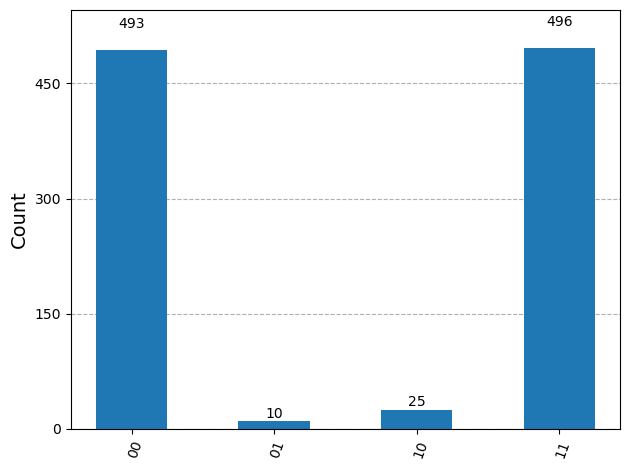

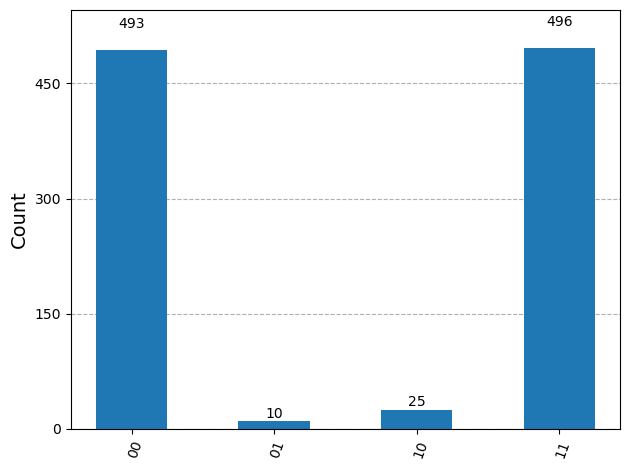

In [31]:
# SamplerV2 returns a list of PubResult objects (one per circuit submitted).
# Counts live under data.<classical_register_name>.get_counts().
# Because our circuit was built with QuantumCircuit(2, 2) the default
# classical register name is "c".
counts = result[0].data.c.get_counts()
plot_histogram(counts)

## Summary

In this notebook we:

- Built our first quantum circuit – a **Bell state** – with a Hadamard on qubit 0 followed by a CNOT.
- Ran it on a local simulator using `qiskit-aer` (`AerSimulator`).
- Submitted the same circuit to a real IBM Quantum computer using `qiskit-ibm-runtime` and the `SamplerV2` primitive.

In the next notebooks we will explore phase, the Bloch sphere, and richer multi-qubit algorithms.